In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [ ]:
url = "https://raw.githubusercontent.com/SagarChhabriya/data-science/refs/heads/main/datasets/TBD/salary_dataset.csv"

df = pd.read_csv(url)

df.head()

,Experience Years,Salary
0,0.6,27868
1,0.6,31381
2,0.7,44204
3,0.8,39551
4,0.9,25984


In [ ]:
df.shape

(200, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  200 non-null    float64
 1   Salary            200 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.3 KB


In [ ]:
df.describe()

,Experience Years,Salary
count,200.000000,200.000000
mean,7.519000,96834.455000
std,4.279792,40938.012116
min,0.600000,25984.000000
25%,3.800000,60248.500000
50%,7.700000,94732.000000
75%,11.500000,132854.500000
max,14.800000,173265.000000


In [ ]:
df.isnull().sum()

,0
Experience Years,0
Salary,0


In [ ]:
df.duplicated().sum()

np.int64(0)

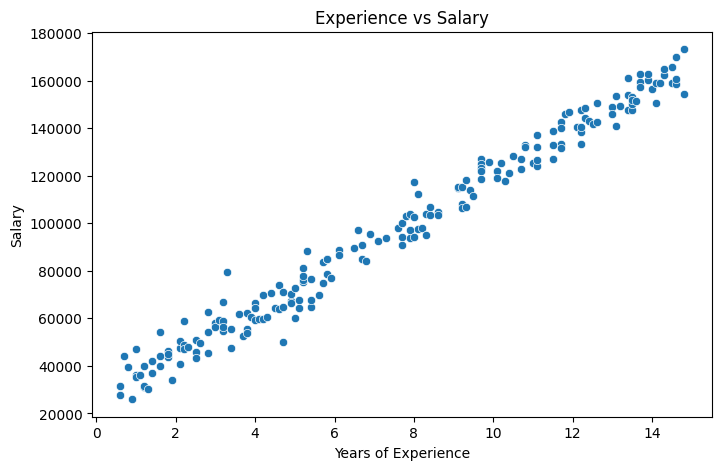

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Experience Years",
    y="Salary"
)

plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

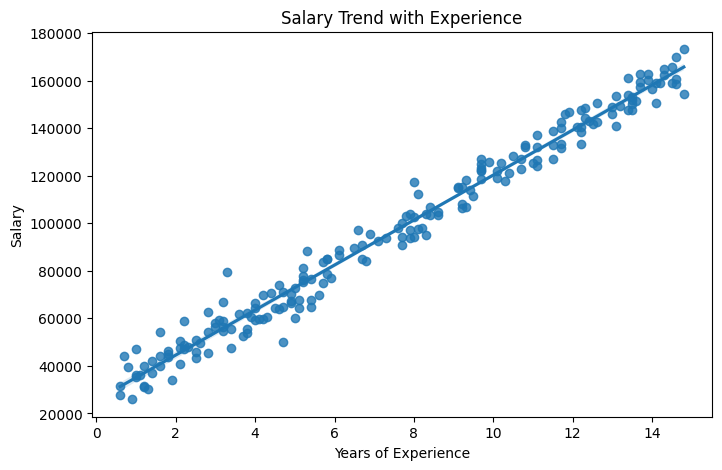

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Experience Years",
    y="Salary"
)

plt.title("Salary Trend with Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [ ]:
df.corr(numeric_only=True)

,Experience Years,Salary
Experience Years,1.000000,0.989868
Salary,0.989868,1.000000


The scatter plot shows a strong upward relationship between years of experience and salary. Employees with more years of experience generally have higher salaries. The regression line also follows the overall pattern of the data quite closely. The correlation coefficient of approximately 0.99 confirms that the two variables have a very strong positive linear relationship. Based on this pattern, Linear Regression is a suitable model to test for salary prediction.

In [ ]:
X = df[["Experience Years"]]
y = df["Salary"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (200, 1)
Target shape: (200,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 1)
Testing data: (40, 1)


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 25755.14781172425
Coefficient: 9437.993959443527


In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 90877.30613188  40855.93814683  49350.13271033 139954.87472099
 117303.68921833 105034.29707105  72945.11760894 148449.06928449
 152224.26686827  57844.32727383]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 4056.343861389738
Mean Squared Error (MSE): 23745684.254818656
Root Mean Squared Error (RMSE): 4872.954366174452
R² Score: 0.9831368268457784


The Linear Regression model achieved an R² score of approximately 0.983, meaning that the model explains about 98.3% of the variation in salary within the test data. The MAE is approximately 4,056, so the predictions differ from the actual salaries by around 4,056 on average. The RMSE is approximately 4,873, which indicates the typical size of the prediction error while giving more weight to larger errors. Overall, the model fits this particular dataset closely

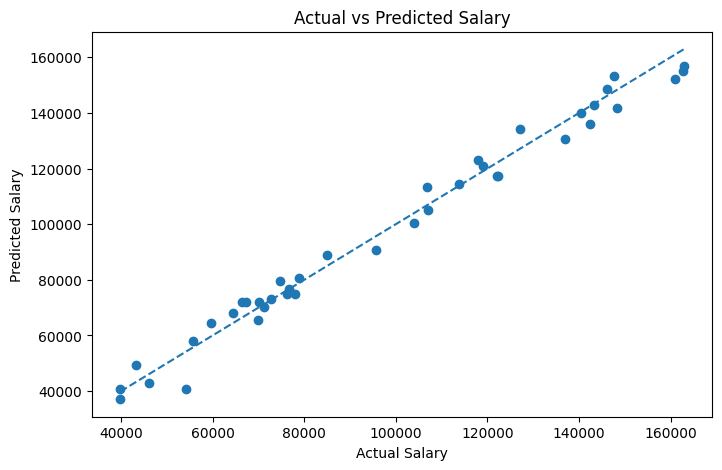

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

Actual vs Predicted Salary:
The predicted values are generally close to the actual salary values, as most points are positioned near the diagonal reference line. There is some variation between the predictions and actual values, but the overall pattern remains close to the expected line. This visual result is consistent with the high R² score obtained from the model.

In [ ]:
joblib.dump(model, "salary_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print(os.listdir())

['.config', 'salary_model.pkl', 'sample_data']


In [ ]:
df.to_csv("salary_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
